# Bitcoin Price Prediction  - Sequencing approach

In [2]:
import numpy as np
import pandas as pd 
from sklearn.linear_model import LinearRegression, SGDRegressor
import matplotlib.pyplot as plt 

In [3]:
df = pd.read_csv("BTC-USD.csv")
df

,Date,Open,High,Low,Close,Adj Close,Volume
0,2014-10-07,330.584015,339.247009,320.481995,336.187012,336.187012,49199900
1,2014-10-08,336.115997,354.364014,327.187988,352.940002,352.940002,54736300
2,2014-10-09,352.747986,382.726013,347.687012,365.026001,365.026001,83641104
3,2014-10-10,364.687012,375.066986,352.963013,361.562012,361.562012,43665700
4,2014-10-11,361.362000,367.191010,355.950989,362.299011,362.299011,13345200
...,...,...,...,...,...,...,...
3550,2024-06-26,61789.675781,62434.136719,60695.187500,60811.277344,60811.277344,22506003064
3551,2024-06-27,60811.226562,62293.863281,60585.332031,61604.800781,61604.800781,21231745045
3552,2024-06-28,61612.804688,62126.097656,59985.402344,60320.136719,60320.136719,24952866877
3553,2024-06-29,60319.875000,61097.621094,60300.964844,60887.378906,60887.378906,12652903396


In [4]:
df.isna().sum()

Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

In [5]:
# feature engineering
df["logClose_return"]= np.log(df['Close']/ df['Close'].shift(1))
df

,Date,Open,High,Low,Close,Adj Close,Volume,logClose_return
0,2014-10-07,330.584015,339.247009,320.481995,336.187012,336.187012,49199900,NaN
1,2014-10-08,336.115997,354.364014,327.187988,352.940002,352.940002,54736300,0.048630
2,2014-10-09,352.747986,382.726013,347.687012,365.026001,365.026001,83641104,0.033671
3,2014-10-10,364.687012,375.066986,352.963013,361.562012,361.562012,43665700,-0.009535
4,2014-10-11,361.362000,367.191010,355.950989,362.299011,362.299011,13345200,0.002036
...,...,...,...,...,...,...,...,...
3550,2024-06-26,61789.675781,62434.136719,60695.187500,60811.277344,60811.277344,22506003064,-0.016203
3551,2024-06-27,60811.226562,62293.863281,60585.332031,61604.800781,61604.800781,21231745045,0.012965
3552,2024-06-28,61612.804688,62126.097656,59985.402344,60320.136719,60320.136719,24952866877,-0.021074
3553,2024-06-29,60319.875000,61097.621094,60300.964844,60887.378906,60887.378906,12652903396,0.009360


In [6]:
#drop na
df.dropna(inplace=True)

In [7]:
#add price of tomorrow 
df["PriceTomorrow"] = df["Close"].shift(-1)
df.dropna(inplace=True)
df

,Date,Open,High,Low,Close,Adj Close,Volume,logClose_return,PriceTomorrow
1,2014-10-08,336.115997,354.364014,327.187988,352.940002,352.940002,54736300,0.048630,365.026001
2,2014-10-09,352.747986,382.726013,347.687012,365.026001,365.026001,83641104,0.033671,361.562012
3,2014-10-10,364.687012,375.066986,352.963013,361.562012,361.562012,43665700,-0.009535,362.299011
4,2014-10-11,361.362000,367.191010,355.950989,362.299011,362.299011,13345200,0.002036,378.549011
5,2014-10-12,362.605988,379.433014,356.144012,378.549011,378.549011,17552800,0.043876,390.414001
...,...,...,...,...,...,...,...,...,...
3549,2024-06-25,60266.281250,62258.261719,60239.750000,61804.640625,61804.640625,29201215431,0.025021,60811.277344
3550,2024-06-26,61789.675781,62434.136719,60695.187500,60811.277344,60811.277344,22506003064,-0.016203,61604.800781
3551,2024-06-27,60811.226562,62293.863281,60585.332031,61604.800781,61604.800781,21231745045,0.012965,60320.136719
3552,2024-06-28,61612.804688,62126.097656,59985.402344,60320.136719,60320.136719,24952866877,-0.021074,60887.378906


In [38]:
# Wrong y = df["PriceTomorrow"]
df["LogReturnTomorrow"] = df["logClose_return"].shift(-1)
df.dropna(inplace=True)
X = df['logClose_return']
X
y = df["LogReturnTomorrow"]
y

1       0.033671
2      -0.009535
3       0.002036
4       0.043876
5       0.030862
          ...   
3547   -0.047043
3548    0.025021
3549   -0.016203
3550    0.012965
3551   -0.021074
Name: LogReturnTomorrow, Length: 3551, dtype: float64

In [39]:
# split 
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, shuffle=False)
type(X_train)

pandas.core.series.Series

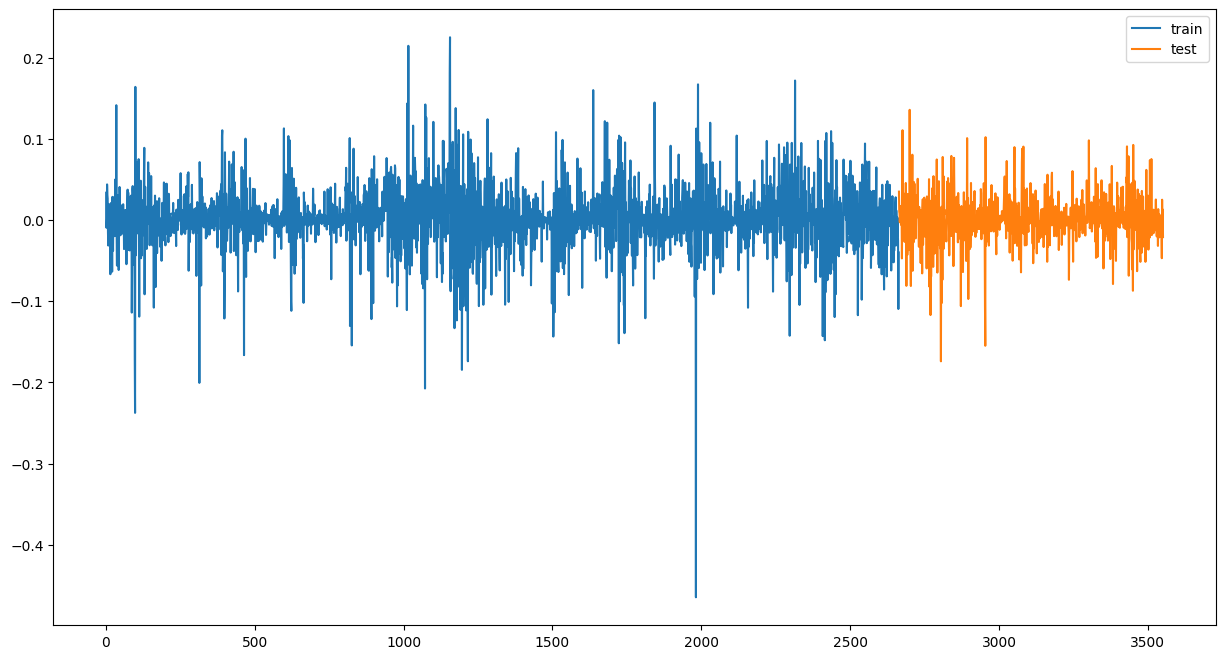

In [40]:
plt.figure(figsize=(15, 8))
plt.plot(y_train,label="train")
plt.plot(y_test,label ="test")
plt.legend()


In [41]:
# sequencing X_train y_train
n_samples= X_train.shape[0]
n_sequence = 7
X_train_batch=[]
y_train_batch=[]
#n_samples[0]
for i in range(0,n_samples-n_sequence):
    batch_train = X_train.iloc[i: i + n_sequence]
    X_train_batch.append(batch_train)

    y_train_new = y_train.iloc[i + n_sequence] 
    y_train_batch.append(y_train_new)
    
print(len(X_train_batch))
print(len(y_train_batch))
print(type(X_train_batch))
X_train_batch

2656
2656
<class 'list'>


[1    0.048630
 2    0.033671
 3   -0.009535
 4    0.002036
 5    0.043876
 6    0.030862
 7    0.026429
 Name: logClose_return, dtype: float64,
 2    0.033671
 3   -0.009535
 4    0.002036
 5    0.043876
 6    0.030862
 7    0.026429
 8   -0.015326
 Name: logClose_return, dtype: float64,
 3   -0.009535
 4    0.002036
 5    0.043876
 6    0.030862
 7    0.026429
 8   -0.015326
 9   -0.031436
 Name: logClose_return, dtype: float64,
 4     0.002036
 5     0.043876
 6     0.030862
 7     0.026429
 8    -0.015326
 9    -0.031436
 10    0.003137
 Name: logClose_return, dtype: float64,
 5     0.043876
 6     0.030862
 7     0.026429
 8    -0.015326
 9    -0.031436
 10    0.003137
 11    0.019825
 Name: logClose_return, dtype: float64,
 6     0.030862
 7     0.026429
 8    -0.015326
 9    -0.031436
 10    0.003137
 11    0.019825
 12   -0.004855
 Name: logClose_return, dtype: float64,
 7     0.026429
 8    -0.015326
 9    -0.031436
 10    0.003137
 11    0.019825
 12   -0.004855
 13   -0.0173

In [42]:
# sequencing X_test y_test
n_samples= X_test.shape[0]
n_sequence = 7
X_test_batch=[]
y_test_batch=[]

for i in range(0,n_samples-n_sequence):
    batch_test = X_test.iloc[i: i + n_sequence]
    X_test_batch.append(batch_test)

    y_test_new = y_test.iloc[i + n_sequence] 
    y_test_batch.append(y_test_new)
    
print(len(X_test_batch))
print(len(y_test_batch))

881
881


In [43]:
print("X_test rows:", X_test.shape[0])  # 889
print("n_sequence:", n_sequence)        # 7
print("Batches:", X_test.shape[0] - n_sequence)  # 882

X_test rows: 888
n_sequence: 7
Batches: 881


In [44]:
#invert list to array (which models can work with)
X_train_array = np.array(X_train_batch)  # Shape: (n_batches, n_sequence)
X_test_array = np.array(X_test_batch)    # Shape: (n_batches, n_sequence)

y_train_array = np.array(y_train_batch)
y_test_array = np.array(y_test_batch)

In [45]:
print("X_train shape:", X_train_array.shape) 
print("X_test shape:", X_test_array.shape)    
print("y_train shape:", y_train_array.shape)  
print("y_test shape:", y_test_array.shape)    

X_train shape: (2656, 7)
X_test shape: (881, 7)
y_train shape: (2656,)
y_test shape: (881,)


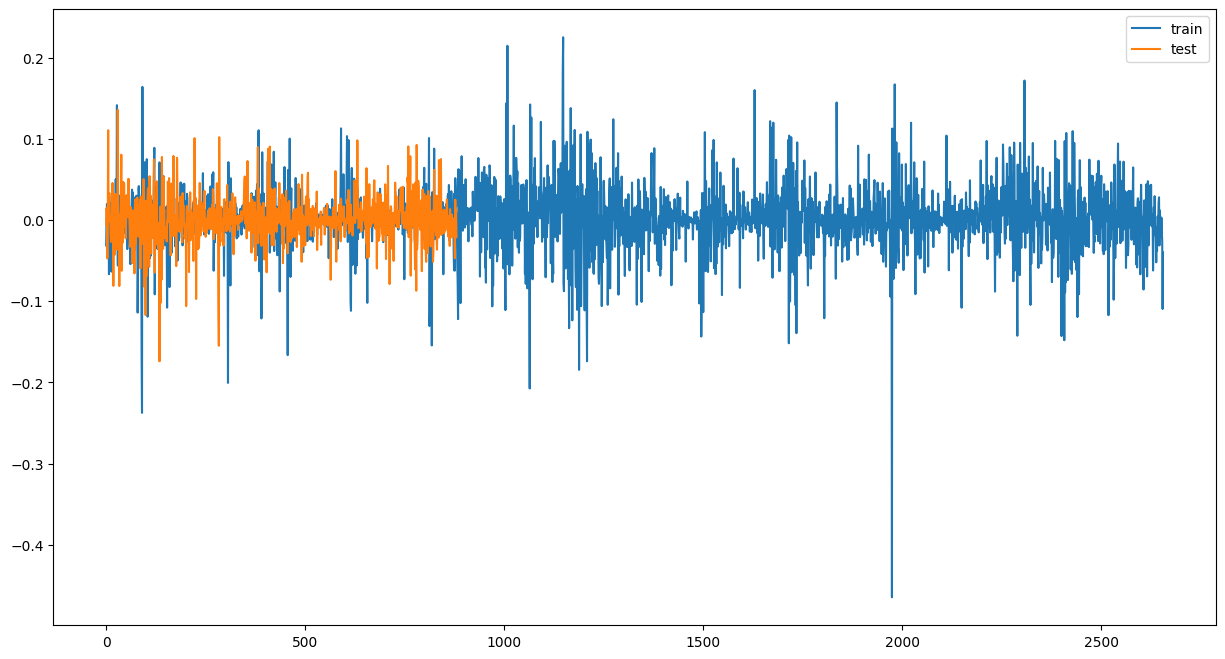

In [46]:
plt.figure(figsize=(15, 8))
plt.plot(y_train_array,label="train")
plt.plot(y_test_array,label ="test")
plt.legend()


In [133]:
#pipeline
from sklearn.pipeline import Pipeline

In [134]:
pipeline = Pipeline([
    ('model', SGDRegressor(max_iter=1000, random_state=42,penalty = 'l2'))
]) 
pipeline

,steps,"[('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,loss,'squared_error'
,penalty,'l2'
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,1000
,tol,0.001


In [135]:
#train
pipeline.fit(X_train_array, y_train_array)

,steps,"[('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,loss,'squared_error'
,penalty,'l2'
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,1000
,tol,0.001


In [136]:
# Predict
y_pred_test = pipeline.predict(X_test_array)

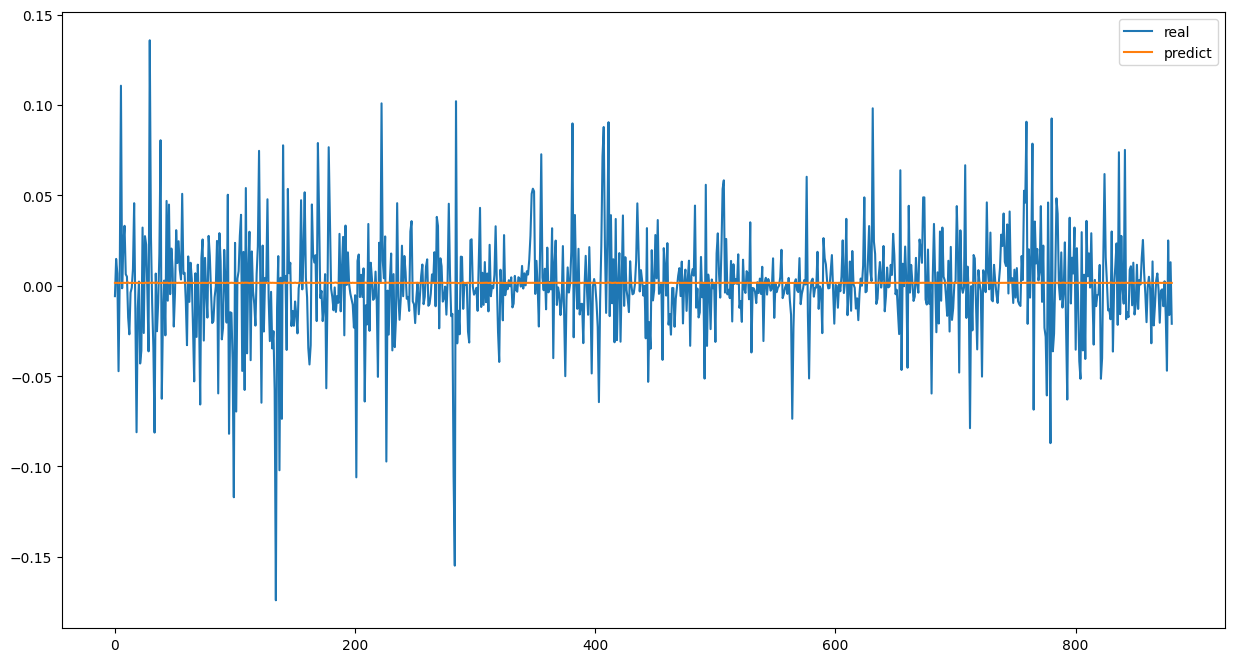

In [168]:
plt.figure(figsize=(15, 8))
plt.plot(y_test_array,label='real')
plt.plot(y_pred_test,label="predict")
plt.legend()

In [138]:
#find base line = price of today to get real price of tomorrow- tomorrow = today * changes of tomorrow
baseline_price = df["Close"].iloc[len(X_train)+n_sequence : len(X_train)+n_sequence  + len (y_pred_test)]
baseline_price
predicted_price = baseline_price * np.exp(y_pred_test)

predicted_price

2671    38197.714502
2672    37976.529345
2673    38542.980015
2674    38804.721730
2675    37011.549350
            ...     
3547    63277.203927
3548    60372.219870
3549    61900.746795
3550    60904.685207
3551    61700.330087
Name: Close, Length: 881, dtype: float64

In [139]:
real_price = df["Close"].iloc[len(X_train) + n_sequence+1: len(X_train) + n_sequence + 1 + len(y_pred_test)]
real_price

2672    37917.601562
2673    38483.125000
2674    38743.273438
2675    36952.984375
2676    37154.601562
            ...     
3547    63180.796875
3548    60277.414062
3549    61804.640625
3550    60811.277344
3551    61604.800781
Name: Close, Length: 880, dtype: float64

In [140]:
# note the price of  2671    38197.714502 = 2672    37917.601562 
predicted_price = predicted_price[:-1]
len(predicted_price)

880

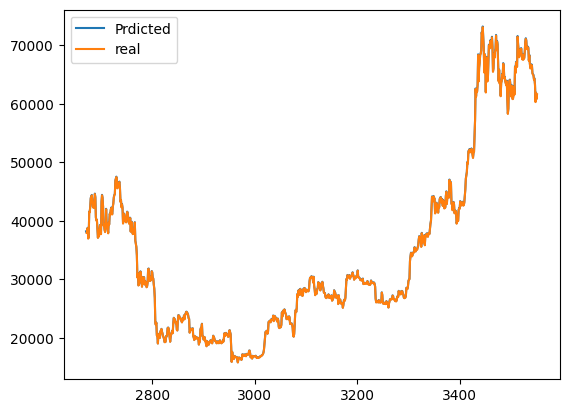

In [169]:
plt.plot(predicted_price,label="Prdicted")
plt.plot(real_price,label = "real")
plt.legend()

In [144]:
# compare the price 
print(predicted_price.iloc[0])
print(real_price.iloc[0])

# 38197.71450177981 VS  
#  37917.6015625

38197.71450177981
37917.6015625


In [145]:
# Evaluateio
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(real_price, predicted_price)
rmse = np.sqrt(mean_squared_error(real_price, predicted_price))

print(f"MAE:  ${mae:.2f}     ← Average error in dollars")
print(f"RMSE: ${rmse:.2f}    ← Penalizes large errors more")

MAE:  $683.05     ← Average error in dollars
RMSE: $1089.05    ← Penalizes large errors more


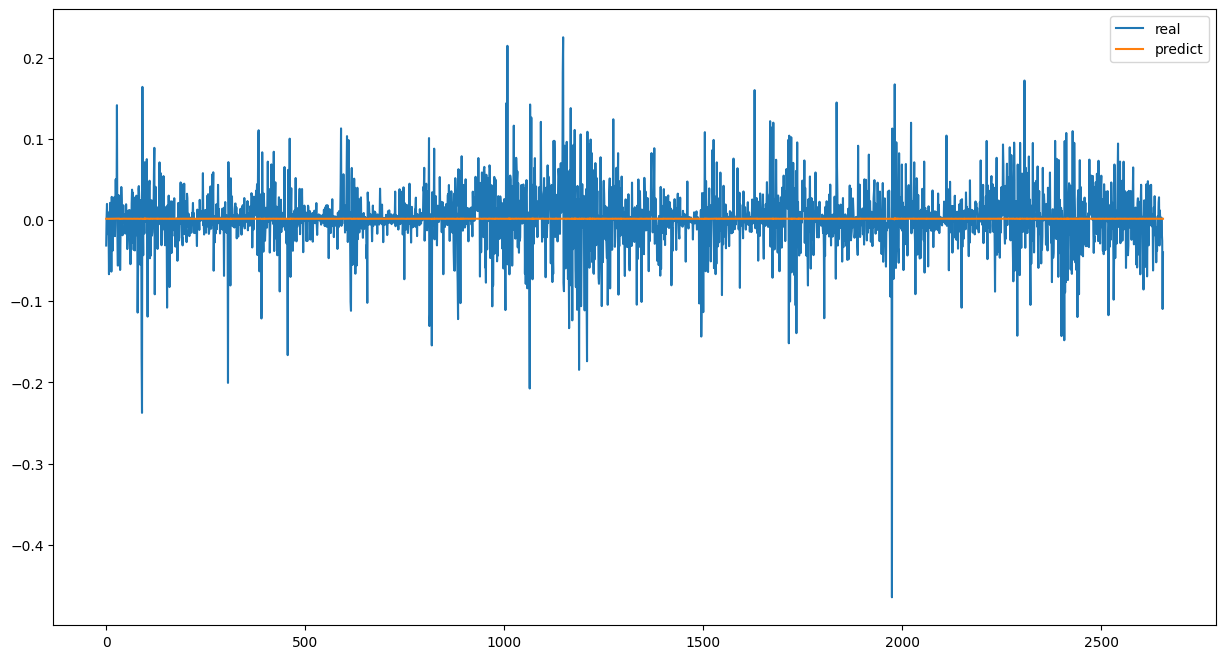

In [170]:
#on  train 
y_pred_train = pipeline.predict(X_train_array)
plt.figure(figsize=(15, 8))
plt.plot(y_train_array,label='real')
plt.plot(y_pred_train,label="predict")
plt.legend()

In [154]:
# 
start_idx_train = n_sequence
baseline_train = df["Close"].iloc[start_idx_train : start_idx_train + len(y_pred_train)]
real_price_train = df["Close"].iloc[start_idx_train + 1 : start_idx_train + 1 + len(y_pred_train)]
predicted_price_train = baseline_train.values * np.exp(y_pred_train)

In [156]:
len(predicted_price_train)

2656

In [157]:
len(real_price_train)

2656

In [162]:
print(predicted_price_train[0])
print(real_price_train.iloc[0])

#395.37301898146103 VS   382.5559997558594

mae_train_dollar = mean_absolute_error(real_price_train, predicted_price_train)
rmse_train_dollar = np.sqrt(mean_squared_error(real_price_train, predicted_price_train))

print(f"Train MAE:  ${mae_train_dollar:,.2f}")
print(f"Train RMSE: ${rmse_train_dollar:,.2f}")

395.37301898146103
382.5559997558594
Train MAE:  $323.98
Train RMSE: $770.87


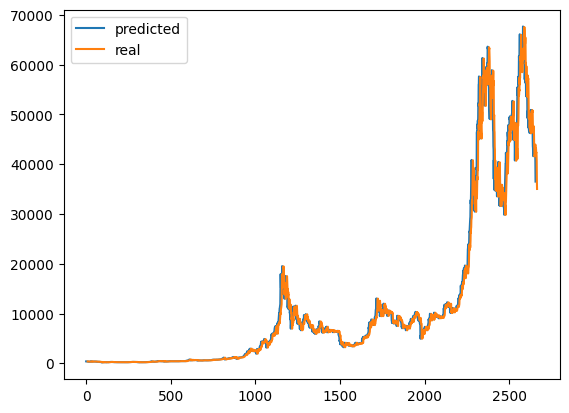

In [172]:
plt.plot(predicted_price_train,label="predicted")
plt.plot(real_price_train,label='real')
plt.legend()

In [167]:
# Overfit or Underfit:
print(f"Train MAE:  ${mae_train_dollar:,.2f}")
print(f"MAE:  ${mae:.2f} Test")

#Overfitted model

Train MAE:  $323.98
MAE:  $683.05 Test
